In [1]:
from pyspark.sql import SparkSession
import os
import sys

In [2]:
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .master("local[*]")    
    .getOrCreate()
)

In [3]:
df = spark.read.csv("housing.csv", header=True, inferSchema=True)

In [4]:
df.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|
|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|
|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|
|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|
|  -122.25|   37.85|              

In [5]:
df.printSchema()

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- ocean_proximity: string (nullable = true)



In [6]:
df.summary().show()

+-------+-------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+---------------+
|summary|          longitude|         latitude|housing_median_age|       total_rooms|    total_bedrooms|        population|       households|     median_income|median_house_value|ocean_proximity|
+-------+-------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+---------------+
|  count|              20640|            20640|             20640|             20640|             20433|             20640|            20640|             20640|             20640|          20640|
|   mean|-119.56970445736148| 35.6318614341087|28.639486434108527|2635.7630813953488| 537.8705525375618|1425.4767441860465|499.5396802325581|3.8706710029070246|206855.81690891474|           NULL|
| stddev|  2.0035317

In [7]:
df.columns

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [8]:
df.select("ocean_proximity").distinct().show()

+---------------+
|ocean_proximity|
+---------------+
|         ISLAND|
|     NEAR OCEAN|
|       NEAR BAY|
|      <1H OCEAN|
|         INLAND|
+---------------+



In [9]:
df.groupBy("ocean_proximity").count().show()

+---------------+-----+
|ocean_proximity|count|
+---------------+-----+
|         ISLAND|    5|
|     NEAR OCEAN| 2658|
|       NEAR BAY| 2290|
|      <1H OCEAN| 9136|
|         INLAND| 6551|
+---------------+-----+



In [10]:
df.count(), df.distinct().count()

(20640, 20640)

In [11]:
df = df.dropDuplicates()

In [12]:
from pyspark.sql.functions import col, sum

null_counts = df.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
])
null_counts.show()


+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|        0|       0|                 0|          0|           207|         0|         0|            0|                 0|              0|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+



In [13]:
from pyspark.sql import functions as F

df_null_bedrooms = (
    df
    .filter(F.col("total_bedrooms").isNull())
    .groupBy("ocean_proximity")
    .count()
)

df_null_bedrooms.show()


+---------------+-----+
|ocean_proximity|count|
+---------------+-----+
|     NEAR OCEAN|   30|
|       NEAR BAY|   20|
|      <1H OCEAN|  102|
|         INLAND|   55|
+---------------+-----+



In [14]:
from pyspark.sql import functions as F

mean_by_ocean = (
    df.groupBy("ocean_proximity")
      .agg(F.avg("total_bedrooms").alias("mean_total_bedrooms"))
)

mean_by_ocean.show()

+---------------+-------------------+
|ocean_proximity|mean_total_bedrooms|
+---------------+-------------------+
|         ISLAND|              420.4|
|     NEAR OCEAN|  538.6156773211568|
|       NEAR BAY|  514.1828193832599|
|      <1H OCEAN|  546.5391852999778|
|         INLAND|  533.8816194581281|
+---------------+-------------------+



In [15]:

df = (
    df.join(mean_by_ocean, on="ocean_proximity", how="inner")
      .withColumn(
          "total_bedrooms",
          F.when(F.col("total_bedrooms").isNull(), F.col("mean_total_bedrooms"))
           .otherwise(F.col("total_bedrooms"))
      )
      .drop("mean_total_bedrooms")
)

df.show()


+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|       NEAR BAY|  -122.28|   37.81|              52.0|      340.0|          97.0|     200.0|      87.0|       1.5208|          112500.0|
|       NEAR BAY|  -122.13|   37.67|              40.0|     1748.0|         318.0|     914.0|     317.0|       3.8676|          184000.0|
|       NEAR BAY|  -122.07|   37.67|              27.0|     3239.0|         671.0|    1469.0|     616.0|       3.2465|          230600.0|
|       NEAR BAY|  -122.13|   37.66|              19.0|      862.0|         167.0|     407.0|     183.0|       4.3456|          163000.0|
|         INLAND|  -121.85|   39.7

In [16]:
null_counts = df.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
])
null_counts.show()


+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|              0|        0|       0|                 0|          0|             0|         0|         0|            0|                 0|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+



In [17]:
from pyspark.sql import functions as F

col = "total_rooms"

row = (
    df.where(F.col(col).isNotNull())
      .select(F.min(col).alias("min"), F.max(col).alias("max"))
      .first()
)

mn, mx = float(row["min"]), float(row["max"])


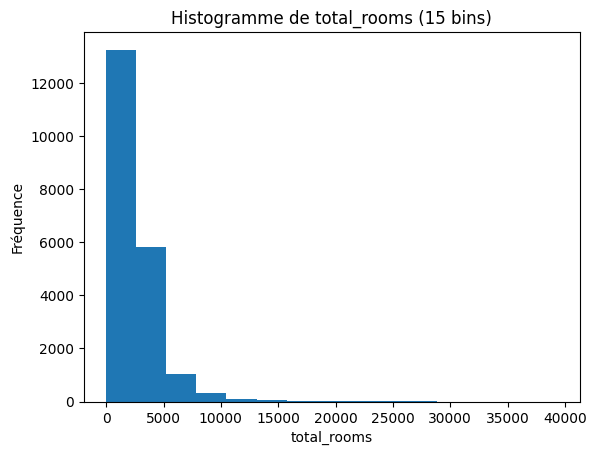

In [18]:
import numpy as np
import matplotlib.pyplot as plt

nbins = 15
bins = np.linspace(mn, mx, nbins + 1).tolist()

bin_edges, counts = (
    df.select(col)
      .where(F.col(col).isNotNull())
      .rdd.map(lambda r: float(r[0]))
      .histogram(bins)
)

widths = np.diff(bin_edges)
plt.figure()
plt.bar(bin_edges[:-1], counts, width=widths, align="edge")
plt.title(f"Histogramme de {col} ({nbins} bins)")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()


In [19]:
from pyspark.sql import functions as F
from pyspark.ml.feature import Bucketizer
import numpy as np
import matplotlib.pyplot as plt

col = "total_rooms"
group_col = "ocean_proximity"
nbins = 15

row = (
    df.where(F.col(col).isNotNull())
      .select(F.min(col).alias("min"), F.max(col).alias("max"))
      .first()
)
mn, mx = float(row["min"]), float(row["max"])


In [20]:
splits = np.linspace(mn, mx, nbins + 1).tolist()

bucketizer = Bucketizer(
    splits=splits,
    inputCol=col,
    outputCol="bucket",
    handleInvalid="skip"  
)

hist_df = (
    bucketizer.transform(df)
      .groupBy(group_col, "bucket")
      .agg(F.count("*").alias("count"))
)


In [21]:
hist_df.show()

+---------------+------+-----+
|ocean_proximity|bucket|count|
+---------------+------+-----+
|     NEAR OCEAN|  11.0|    1|
|      <1H OCEAN|   4.0|   31|
|       NEAR BAY|   4.0|    9|
|     NEAR OCEAN|   6.0|    7|
|       NEAR BAY|   0.0| 1512|
|         INLAND|   3.0|  135|
|         INLAND|   8.0|    4|
|      <1H OCEAN|  10.0|    3|
|         INLAND|  14.0|    1|
|         INLAND|   2.0|  345|
|         INLAND|   1.0| 1813|
|     NEAR OCEAN|   2.0|  116|
|     NEAR OCEAN|   5.0|    5|
|         INLAND|   5.0|   24|
|      <1H OCEAN|  12.0|    2|
|         INLAND|   4.0|   57|
|      <1H OCEAN|   5.0|   22|
|     NEAR OCEAN|   9.0|    2|
|         INLAND|   6.0|   17|
|     NEAR OCEAN|   7.0|    1|
+---------------+------+-----+
only showing top 20 rows


In [22]:
hist_df.count()

45

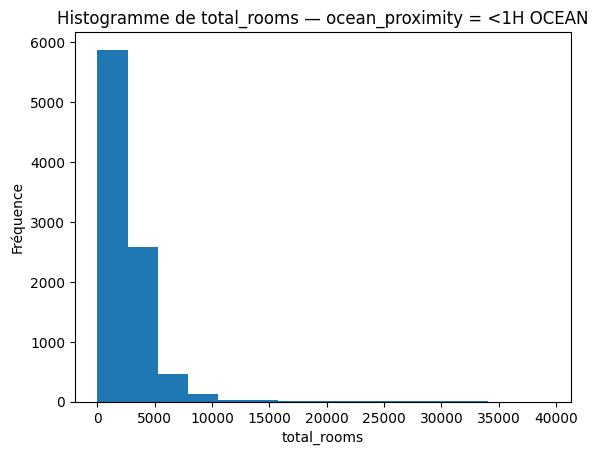

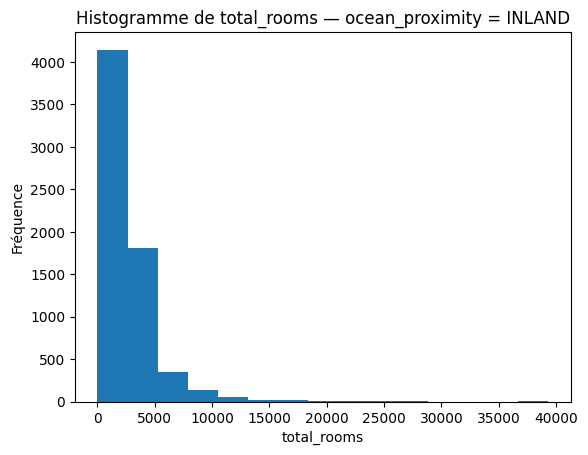

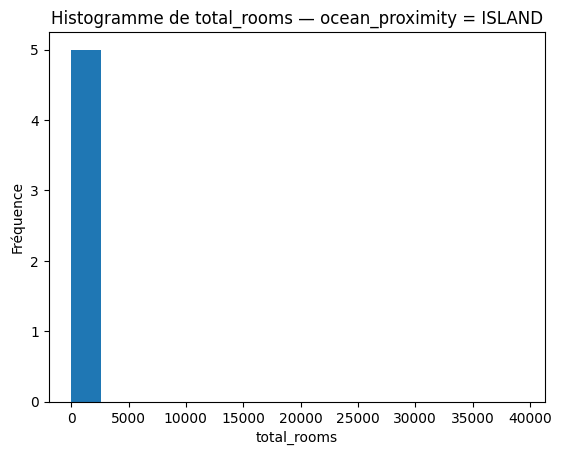

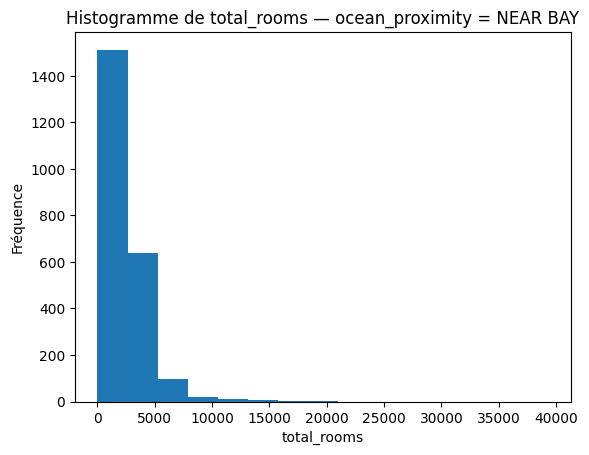

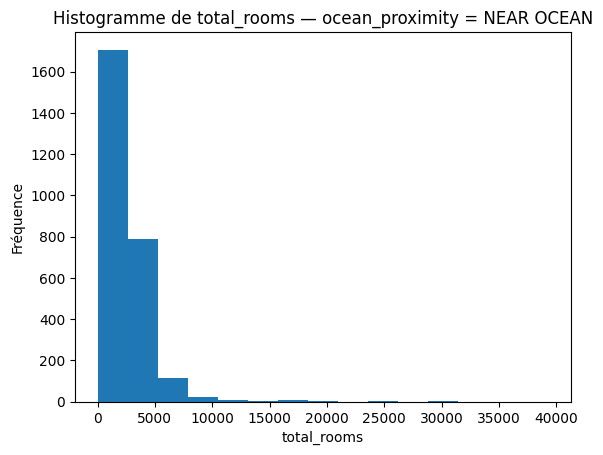

In [23]:
from collections import defaultdict

rows = hist_df.collect() 
counts_by_group = defaultdict(lambda: [0] * nbins)
for r in rows:
    g = r[group_col]
    b = int(r["bucket"])        
    c = int(r["count"])
    if 0 <= b < nbins:
        counts_by_group[g][b] = c

bin_lefts = np.array(splits[:-1])
widths = np.diff(splits)

for g in sorted(k for k in counts_by_group.keys() if k is not None):
    counts = np.array(counts_by_group[g])

    plt.figure()
    plt.bar(bin_lefts, counts, width=widths, align="edge")
    plt.title(f"Histogramme de {col} — {group_col} = {g}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [24]:
counts_by_group

defaultdict(<function __main__.<lambda>()>,
            {'NEAR OCEAN': [1707,
              787,
              116,
              24,
              8,
              5,
              7,
              1,
              0,
              2,
              0,
              1,
              0,
              0,
              0],
             '<1H OCEAN': [5879,
              2577,
              460,
              132,
              31,
              22,
              13,
              6,
              5,
              3,
              3,
              2,
              2,
              0,
              1],
             'NEAR BAY': [1512, 639, 99, 21, 9, 7, 1, 2, 0, 0, 0, 0, 0, 0, 0],
             'INLAND': [4144,
              1813,
              345,
              135,
              57,
              24,
              17,
              9,
              4,
              1,
              1,
              0,
              0,
              0,
              1],
             'ISLAND': [5, 0, 0, 0, 0,

In [25]:
counts_by_group["NEAR BAY"]

[1512, 639, 99, 21, 9, 7, 1, 2, 0, 0, 0, 0, 0, 0, 0]

In [26]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="ocean_proximity", outputCol="ocean_proximity_index")
df = indexer.fit(df).transform(df)

In [27]:
df.show()

+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity_index|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------------+
|       NEAR BAY|  -122.28|   37.81|              52.0|      340.0|          97.0|     200.0|      87.0|       1.5208|          112500.0|                  3.0|
|       NEAR BAY|  -122.13|   37.67|              40.0|     1748.0|         318.0|     914.0|     317.0|       3.8676|          184000.0|                  3.0|
|       NEAR BAY|  -122.07|   37.67|              27.0|     3239.0|         671.0|    1469.0|     616.0|       3.2465|          230600.0|                  3.0|
|       NEAR BAY|  -122.13|   37.66|    

In [28]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', "ocean_proximity_index"],
                                outputCol='features')

df_features = assembler.transform(df)

In [29]:
df_features.show()

+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------------+--------------------+
|ocean_proximity|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity_index|            features|
+---------------+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------------+--------------------+
|       NEAR BAY|  -122.28|   37.81|              52.0|      340.0|          97.0|     200.0|      87.0|       1.5208|          112500.0|                  3.0|[-122.28,37.81,52...|
|       NEAR BAY|  -122.13|   37.67|              40.0|     1748.0|         318.0|     914.0|     317.0|       3.8676|          184000.0|                  3.0|[-122.13,37.67,40...|
|       NEAR BAY|  -122.07|   37.67|              27.0|     3239.0|         671.0|    1469.0|  

In [30]:
final_df = df_features.select('features', 'median_house_value')

In [31]:
final_df.show()

+--------------------+------------------+
|            features|median_house_value|
+--------------------+------------------+
|[-122.28,37.81,52...|          112500.0|
|[-122.13,37.67,40...|          184000.0|
|[-122.07,37.67,27...|          230600.0|
|[-122.13,37.66,19...|          163000.0|
|[-121.85,39.73,52...|          137500.0|
|[-121.85,38.0,26....|          133400.0|
|[-121.87,37.99,15...|          163900.0|
|[-119.98,38.93,25...|           90400.0|
|[-119.78,36.76,47...|           51300.0|
|[-119.6,36.57,42....|           69700.0|
|[-124.05,40.85,31...|          143000.0|
|[-119.77,36.3,24....|           62000.0|
|[-122.68,38.76,29...|           67900.0|
|[-118.36,34.16,45...|          322900.0|
|[-118.35,34.09,47...|          280600.0|
|[-118.19,34.08,35...|          139500.0|
|[-118.33,34.03,46...|          125000.0|
|[-118.31,34.02,46...|          112100.0|
|[-118.25,34.01,45...|           93400.0|
|[-118.28,33.97,31...|          107000.0|
+--------------------+------------

In [32]:
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)


In [33]:
train_df.show()

+--------------------+------------------+
|            features|median_house_value|
+--------------------+------------------+
|[-124.35,40.54,52...|           94600.0|
|[-124.3,41.8,19.0...|           85800.0|
|[-124.27,40.69,36...|           79000.0|
|[-124.26,40.58,52...|          111400.0|
|[-124.25,40.28,32...|           76100.0|
|[-124.23,40.81,52...|           50800.0|
|[-124.22,41.73,28...|           78300.0|
|[-124.21,40.75,32...|           58100.0|
|[-124.21,41.75,20...|           66900.0|
|[-124.21,41.77,17...|           68400.0|
|[-124.19,40.77,30...|           69000.0|
|[-124.19,40.78,37...|           70000.0|
|[-124.19,41.78,15...|           74600.0|
|[-124.18,40.62,35...|          107000.0|
|[-124.18,40.78,33...|           72200.0|
|[-124.18,40.78,37...|           70200.0|
|[-124.18,40.79,39...|           70500.0|
|[-124.18,40.79,40...|           64600.0|
|[-124.17,40.74,17...|          128900.0|
|[-124.17,40.75,13...|          116100.0|
+--------------------+------------

In [34]:
train_df.count(), test_df.count()

(16560, 4080)

In [35]:
from pyspark.ml.regression import LinearRegression

model = LinearRegression(featuresCol='features', labelCol='median_house_value')

model = model.fit(train_df)

In [36]:
model.coefficients

DenseVector([-42997.0804, -42705.2257, 1144.7507, -5.1377, 80.2487, -46.4793, 87.5745, 39356.7959, -1694.6028])

In [37]:
model.intercept


-3603751.8512767125

In [38]:
pred_results = model.evaluate(test_df)

In [39]:
pred_results.predictions.show()

+--------------------+------------------+------------------+
|            features|median_house_value|        prediction|
+--------------------+------------------+------------------+
|[-124.3,41.84,17....|          103600.0|100344.69305936107|
|[-124.23,40.54,52...|          106700.0|190948.54537644004|
|[-124.23,41.75,11...|           73200.0| 74389.69623348024|
|[-124.19,40.73,21...|           90100.0|   161995.62518619|
|[-124.18,40.78,34...|           67000.0|119314.19418764533|
|[-124.17,40.62,32...|           86400.0|155767.61953509878|
|[-124.17,40.79,43...|           70500.0|131146.39291079342|
|[-124.16,40.6,39....|           85100.0| 150338.9322804208|
|[-124.16,40.8,52....|           80500.0|150383.99035083735|
|[-124.16,40.95,20...|           96000.0|133323.71313205827|
|[-124.16,41.02,23...|           75500.0| 98635.51180541655|
|[-124.16,41.92,19...|           75000.0| 50020.76750884438|
|[-124.15,40.76,24...|          100600.0|157233.22008167673|
|[-124.15,40.8,47....|  

In [40]:
pred_results.r2, pred_results.meanAbsoluteError, pred_results.meanSquaredError

(0.6274185468519003, 51789.034789395846, 5154985715.149576)

In [41]:
predictions = model.transform(test_df)

In [42]:
predictions.show()

+--------------------+------------------+------------------+
|            features|median_house_value|        prediction|
+--------------------+------------------+------------------+
|[-124.3,41.84,17....|          103600.0|100344.69305936107|
|[-124.23,40.54,52...|          106700.0|190948.54537644004|
|[-124.23,41.75,11...|           73200.0| 74389.69623348024|
|[-124.19,40.73,21...|           90100.0|   161995.62518619|
|[-124.18,40.78,34...|           67000.0|119314.19418764533|
|[-124.17,40.62,32...|           86400.0|155767.61953509878|
|[-124.17,40.79,43...|           70500.0|131146.39291079342|
|[-124.16,40.6,39....|           85100.0| 150338.9322804208|
|[-124.16,40.8,52....|           80500.0|150383.99035083735|
|[-124.16,40.95,20...|           96000.0|133323.71313205827|
|[-124.16,41.02,23...|           75500.0| 98635.51180541655|
|[-124.16,41.92,19...|           75000.0| 50020.76750884438|
|[-124.15,40.76,24...|          100600.0|157233.22008167673|
|[-124.15,40.8,47....|  

In [43]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="median_house_value",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions) # ou pred_results.predictions
print(f"RMSE = {rmse}")


RMSE = 71798.22919229677


In [44]:
pred_results.rootMeanSquaredError

71798.22919229677